In [5]:
import os

os.makedirs("traffic_sign_det", exist_ok=True)

In [6]:
import os
os.chdir('/content/traffic_sign_det')
print(os.getcwd())

/content/traffic_sign_det


In [7]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="####################")
project = rf.workspace("faculty-of-electrical-engineering-computer-science-and-information-technology-osijek").project("traffic-sign-l3jo2")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 56.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to traffic-sign-2 in yolov8:: 100%|██████████| 3488/3488 [00:00<00:00, 6841.47it/s]


In [8]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.4 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/traffic_sign_det/traffic-sign-2/data.yaml",
    epochs=100,
    imgsz=640
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/traffic_sign_det/traffic-sign-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  4,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b456e40e7e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.0

In [16]:
from ultralytics import YOLO
import os

model = YOLO("/content/traffic_sign_det/runs/detect/train-2/weights/best.pt")

folder_dir = "/content/traffic_sign_det/traffic-sign-2/test/images/"

for image_name in os.listdir(folder_dir):
    if image_name.endswith(".jpg"):

        image_path = os.path.join(folder_dir, image_name)

        results = model.predict(
            source=image_path,
            conf=0.25,
            save=True
        )

        print(f"Processed: {image_name}")


image 1/1 /content/traffic_sign_det/traffic-sign-2/test/images/stop_1323804359-avi_image14_png_jpg.rf.35d4a55d509b6794be00b977c38d10ae.jpg: 640x640 (no detections), 7.5ms
Speed: 4.1ms preprocess, 7.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/traffic_sign_det/runs/detect/predict
Processed: stop_1323804359-avi_image14_png_jpg.rf.35d4a55d509b6794be00b977c38d10ae.jpg

image 1/1 /content/traffic_sign_det/traffic-sign-2/test/images/000682_jpg.rf.700e3476ae3a02c57e980c430086a72a.jpg: 640x640 1 Speed Limit 80, 8.5ms
Speed: 1.9ms preprocess, 8.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/traffic_sign_det/runs/detect/predict
Processed: 000682_jpg.rf.700e3476ae3a02c57e980c430086a72a.jpg

image 1/1 /content/traffic_sign_det/traffic-sign-2/test/images/00125-1-_jpg.rf.52deca5ed0558cc42377e155fe59638a.jpg: 640x640 1 Speed Limit 50, 7.3ms
Speed: 1.5ms preprocess, 7.3ms inference, 1.2ms postprocess per


image 1/1 /content/traffic_sign_det/traffic-sign-2/test/images/000633_jpg.rf.67f5e1c24ef6fc4841cbf913ce8d9f42.jpg: 640x640 1 Speed Limit 80, 11.9ms
Speed: 2.2ms preprocess, 11.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Showing: 000633_jpg.rf.67f5e1c24ef6fc4841cbf913ce8d9f42.jpg


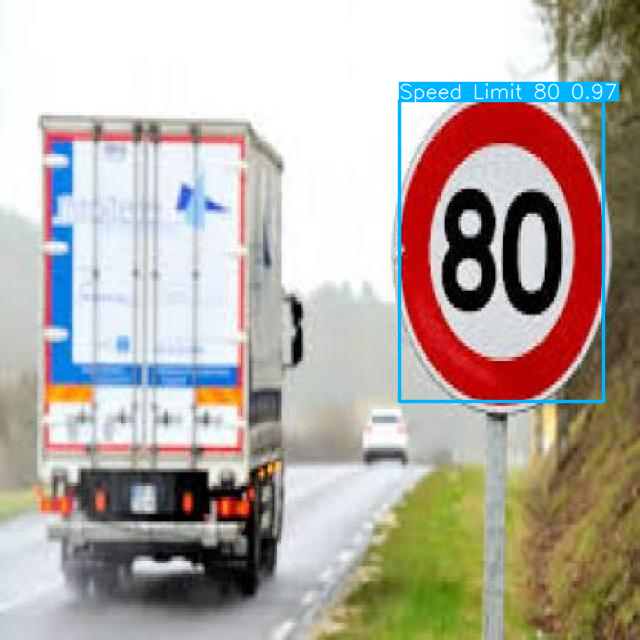

In [17]:
import os
import random
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

model = YOLO("/content/traffic_sign_det/runs/detect/train-2/weights/best.pt")

folder = "/content/traffic_sign_det/traffic-sign-2/test/images/"
images = [f for f in os.listdir(folder) if f.endswith(".jpg")]

sample_img = random.choice(images)
img_path = os.path.join(folder, sample_img)

results = model.predict(source=img_path, conf=0.25)

annotated = results[0].plot()

print("Showing:", sample_img)
cv2_imshow(annotated)

In [ ]:
model.export(format="onnx") #If you want compatibility with ROS, C++, or multiple frameworks
model.export(format="engine") #If you need higher FPS in CARLA
model.export(format="openvino") # FOR CPU


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/traffic_sign_det/runs/detect/train-2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 41, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 318ms
Prepared 4 packages in 1.75s
Installed 4 packages in 232ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 4.3s, saved as '/c